In [86]:
import convokit
import pandas as pd
import nltk
import spacy
nlp = spacy.load("en_core_web_sm")

In [87]:
import zipfile
import os
from convokit import Corpus

# zip_path = "PhD.corpus.zip"
#with zipfile.ZipFile(zip_path, 'r') as zip_ref:
 #   zip_ref.extractall(extract_path)
corpus = Corpus(filename = "phd_data", utterance_start_index=100, utterance_end_index=10100)
# zip_path2 = "teenagers.corpus.zip"
extract_path2 = "teenagers_data"

# with zipfile.ZipFile(zip_path2, 'r') as zip_ref2:
#    zip_ref2.extractall(extract_path2)

corpus_teen = Corpus(filename = "teenagers_data", utterance_start_index=1000000, utterance_end_index=1010000)
corpus.print_summary_stats()
corpus_teen.print_summary_stats()

Number of Speakers: 2700
Number of Utterances: 10001
Number of Conversations: 2908
Number of Speakers: 1699
Number of Utterances: 10001
Number of Conversations: 575


In [88]:
df1 = corpus.get_utterances_dataframe()
display(df1[['text', 'speaker', 'timestamp']].head(3))
df2 = corpus.get_speakers_dataframe()
display(df2.head())

,text,speaker,timestamp
id,,,
4ckawb,I am a UK student currently looking for a PhD....,lscanlon93,1459336317
4cr10i,,spuriousmonkey,1459444916
4cwfd9,So I've been lucky enough to be accepted onto ...,AnonymousSociologist,1459527268


,vectors
id,
lscanlon93,[]
spuriousmonkey,[]
AnonymousSociologist,[]
uniqueusername37,[]
potatopotatopatato,[]


In [89]:
df3 = corpus_teen.get_utterances_dataframe()
display(df3[['text', 'speaker', 'timestamp']].head(5))

,text,speaker,timestamp
id,,,
c3ysnyk,"From a girl's point of view, unless this girl ...",imagirlmessageme,1331177674
c3yso1h,OP?\n\nIdiots should know when they're idiots.,looc22,1331177685
c3yso5l,"I'd be so down for this, let me know.",Solunity,1331177704
c3ysocp,Since I'm in a language program (Spanish-Engli...,[deleted],1331177733
c3ysofb,[Underneath the Weeping Willow by Grandaddy](h...,that_taylor_kid,1331177745


In [90]:
df1['text'].shape
# df3['text'].shape

(10001,)

In [91]:
df1['label'] = "PhD"
df3['label'] = "teen"
merge1 = pd.concat([df1, df3], ignore_index = True)

In [92]:
from sklearn.model_selection import train_test_split
input = merge1['text']
output = merge1['label']
input_train, input_test, output_train, output_test = train_test_split(
    input, output, test_size = 0.2, random_state = 70565
)

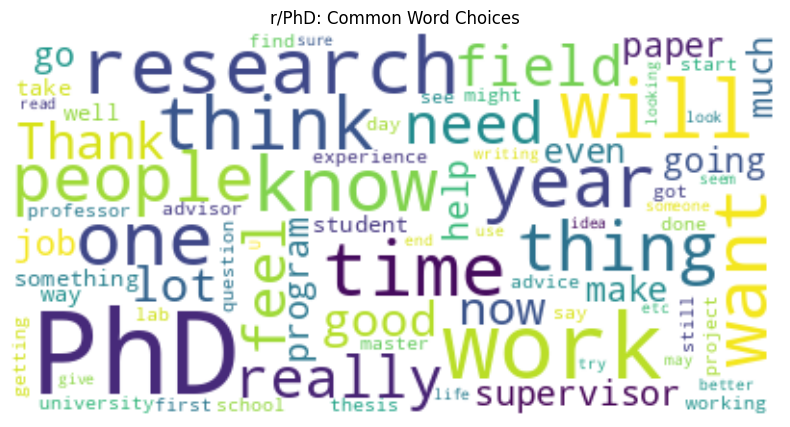

In [93]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt
PHD = " ".join(text for text in merge1[merge1['label']=='PhD'].text)
wc1 = WordCloud(max_font_size = 60, max_words = 75, background_color = 'white').generate(PHD)
plt.figure(figsize=(10,5))
plt.imshow(wc1, interpolation = 'bilinear')
plt.axis("off")
plt.title("r/PhD: Common Word Choices")
plt.show()

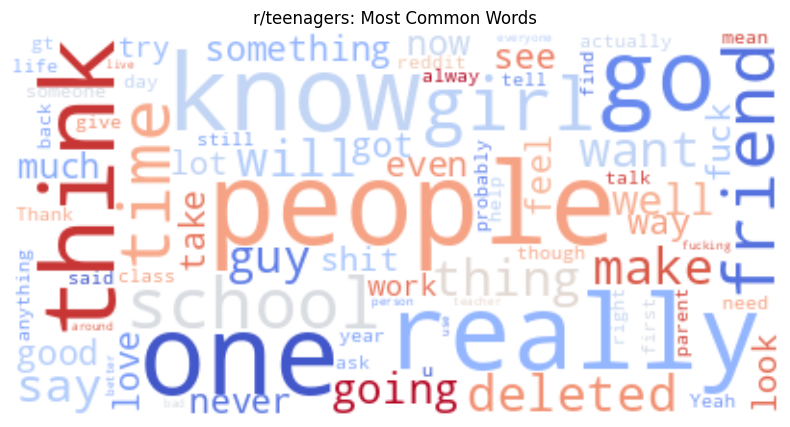

In [94]:
# same code, replace phd with teen
teens = " ".join(text for text in merge1[merge1['label']=='teen'].text)
wc_teen = WordCloud(max_font_size = 60, max_words = 75, colormap = 'coolwarm', background_color = 'white').generate(teens)
plt.figure(figsize=(10,5))
plt.imshow(wc_teen, interpolation='bilinear')
plt.axis("off")
plt.title("r/teenagers: Most Common Words")
plt.show()

In [95]:
from sklearn.feature_extraction.text import CountVectorizer
vectorizer = CountVectorizer()
train_input_vectors = vectorizer.fit_transform(input_train)

In [96]:
from sklearn import svm
clf_svm = svm.SVC(kernel="linear")
clf_svm.fit(train_input_vectors, output_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'linear'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [97]:
test_input = vectorizer.transform(input_test)
result = clf_svm.predict(test_input)

In [98]:
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(output_test, result)
accuracy

0.818045488627843

In [99]:
# Model achieved 82% accuracy, not bad for a bag of words model.
# Will update the model to TF-IDF to see if it leads to marginal improvement in accuracy.
# Will also try doing n-gram model (may help with phrases like graduate school vs. high school.)

In [100]:
from sklearn.feature_extraction.text import TfidfVectorizer
tf_vectorizer = TfidfVectorizer()
train_input_vectors = tf_vectorizer.fit_transform(input_train)

In [101]:
clf_svm = svm.SVC(kernel="linear")
clf_svm.fit(train_input_vectors, output_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'linear'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [102]:
test_input = tf_vectorizer.transform(input_test)
result = clf_svm.predict(test_input)

In [103]:
from sklearn.metrics import accuracy_score
accuracy2 = accuracy_score(output_test, result)
accuracy2

0.8395401149712571

In [104]:
# TF-IDF leads to marginal increase in accuracy, around 3%.

In [105]:
# tinker with the min/max here, could lead to better accuracy
# find a way to compare without manually adjusting?

vectorizer_n = CountVectorizer(ngram_range = (1, 2),
                                            min_df=10,
                                            max_df=0.65)
train_input_vectors = vectorizer_n.fit_transform(input_train)


In [106]:
clf_svm = svm.SVC(kernel="linear")
clf_svm.fit(train_input_vectors, output_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'linear'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [107]:
test_input = vectorizer_n.transform(input_test)
result = clf_svm.predict(test_input)

In [108]:
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(output_test, result)
accuracy

0.8107973006748312

In [109]:
# n-gram model actually decreased accuracy with a variety of parameters
# once eliminating very infrequent phrases/words, accuracy improved but still doesn't match TF-IDF

In [110]:
# TF-IDF has been determined to be the best vectorization method
# Attempt at cross fold validation to see if above result holds for different iterations of the data

In [111]:
from sklearn.model_selection import cross_validate, KFold
from sklearn.metrics import make_scorer, f1_score
import numpy as np

# geeks for geeks recommends k = 5 as a "small but effective" k but it still takes a while to run :(

input3 = tf_vectorizer.fit_transform(merge1['text'])
output3 = merge1['label']
folds = KFold(n_splits=5, shuffle=True, random_state=70565) #random seed as my zip code

scoring = {
    'accuracy': 'accuracy',
    'f1_macro': 'f1_macro',
    'f1_1': make_scorer(f1_score, pos_label='PhD'),
    'f1_2': make_scorer(f1_score, pos_label='teen')
}


cv_results = cross_validate(clf_svm, input3, output3, cv = folds, scoring=scoring)

In [112]:
print(f"Mean Accuracy: {np.mean(cv_results['test_accuracy']):.3f}")
print(f"Standard Deviation: {np.std(cv_results['test_accuracy']):.3f}")

print(f"F1 Score for r/PhD: {np.mean(cv_results['test_f1_1']):.3f}")
print(f"F1 Score for r/teenagers: {np.mean(cv_results['test_f1_2']):.3f}")

print(f"Mean F1 Macro: {np.mean(cv_results['test_f1_macro']):.3f}")



Mean Accuracy: 0.849
Standard Deviation: 0.007
F1 Score for r/PhD: 0.835
F1 Score for r/teenagers: 0.862
Mean F1 Macro: 0.848


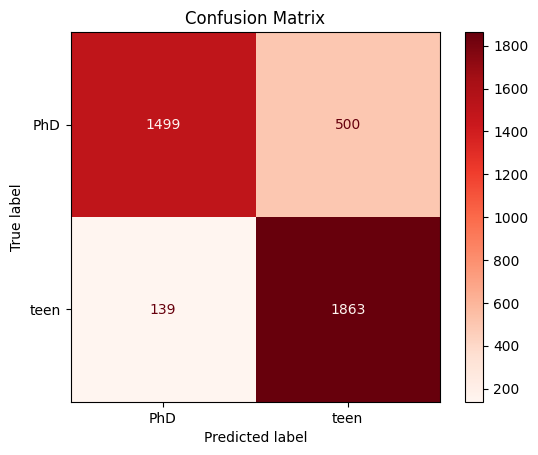

In [113]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

input_train2, input_test2, output_train2, output_test2 = train_test_split(input3, output3, test_size=0.2, random_state=70565)
clf_svm.fit(input_train2, output_train2)
SVM_prediction = clf_svm.predict(input_test2)

chart = confusion_matrix(output_test2, SVM_prediction, labels=['PhD', 'teen'])
actual_grid = ConfusionMatrixDisplay(confusion_matrix = chart, display_labels=['PhD', 'teen'])

actual_grid.plot(cmap = plt.cm.Reds)
plt.title("Confusion Matrix")
plt.show()